In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.api as smt

Загрузка данных

In [2]:
import pandas as pd

sales = pd.read_csv("monthly-sales-of-company-x-jan-6.csv")
robberies = pd.read_csv("monthly-boston-armed-robberies-j.csv")
airlines = pd.read_csv("international-airline-passengers.csv")
temperature = pd.read_csv("mean-monthly-air-temperature-deg.csv")
dowjones = pd.read_csv("weekly-closings-of-the-dowjones-.csv")
births = pd.read_csv("daily-total-female-births-in-cal.csv")

In [4]:
# переименовываю колонку со значениями в Count
sales.columns = ["Date", "Count"]
robberies.columns = ["Date", "Count"]
airlines.columns = ["Date", "Count"]
temperature.columns = ["Date", "Count"]
dowjones.columns = ["Date", "Count"]
births.columns = ["Date", "Count"]

In [5]:
# собрала все в один словарь, чтобы было проще работать
series_dict = {
    "Sales": sales["Count"],
    "Robberies": robberies["Count"],
    "Airlines": airlines["Count"],
    "Temperature": temperature["Count"],
    "DowJones": dowjones["Count"],
    "Births": births["Count"]
}

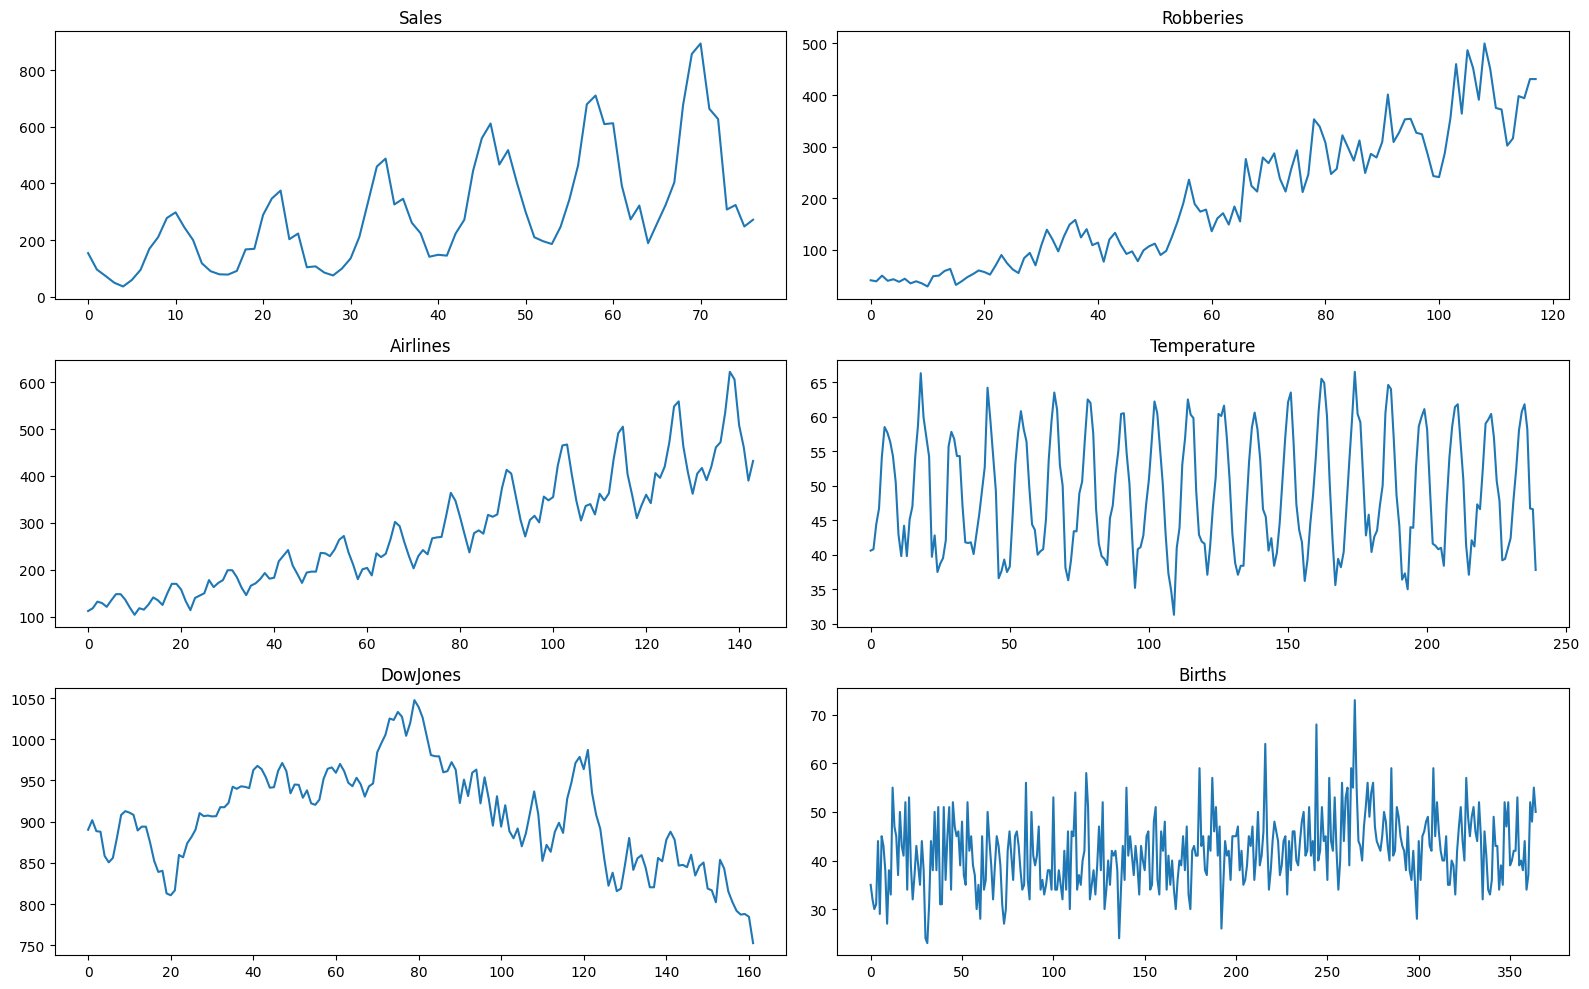

In [6]:
# смотрю как выглядят ряды
plt.figure(figsize=(16, 10))

for i, key in enumerate(series_dict):
    plt.subplot(3, 2, i + 1)
    plt.plot(series_dict[key])
    plt.title(key)

plt.tight_layout()
plt.show()

In [7]:
# функция для теста Дики-Фуллера
def adf_test(series, name=""):
    result = adfuller(series)

    print(f"{name}")
    print("stat:", result[0])
    print("p-value:", result[1])
    print("-" * 30)

In [8]:
# проверяю исходные ряды
for name, series in series_dict.items():
    adf_test(series, name)

Sales
stat: 0.6547150829524446
p-value: 0.9888894205170052
------------------------------
Robberies
stat: 1.001102140245781
p-value: 0.994277563805723
------------------------------
Airlines
stat: 0.8153688792060498
p-value: 0.991880243437641
------------------------------
Temperature
stat: -3.2554924030863366
p-value: 0.016989030222608604
------------------------------
DowJones
stat: -1.3146254984911683
p-value: 0.6224548515589733
------------------------------
Births
stat: -4.808291253559765
p-value: 5.2434129901498554e-05
------------------------------


In [16]:
# функция: делаю ряд более стационарным
def make_stationary(series, diff_order=1):
    # логарифмирование
    series_boxcox = boxcox(series, 0)

    # дифференцирование (можно больше 1 раза)
    series_diff = np.diff(series_boxcox, diff_order)

    return series_diff

In [17]:
# применяю ко всем
sales_st = make_stationary(series_dict["Sales"])
robberies_st = make_stationary(series_dict["Robberies"])
airlines_st = make_stationary(series_dict["Airlines"], diff_order=2)
temperature_st = make_stationary(series_dict["Temperature"])
dowjones_st = make_stationary(series_dict["DowJones"])
births_st = make_stationary(series_dict["Births"])

In [18]:
# собрираю новые ряды
stationary_dict = {
    "Sales": sales_st,
    "Robberies": robberies_st,
    "Airlines": airlines_st,
    "Temperature": temperature_st,
    "DowJones": dowjones_st,
    "Births": births_st
}

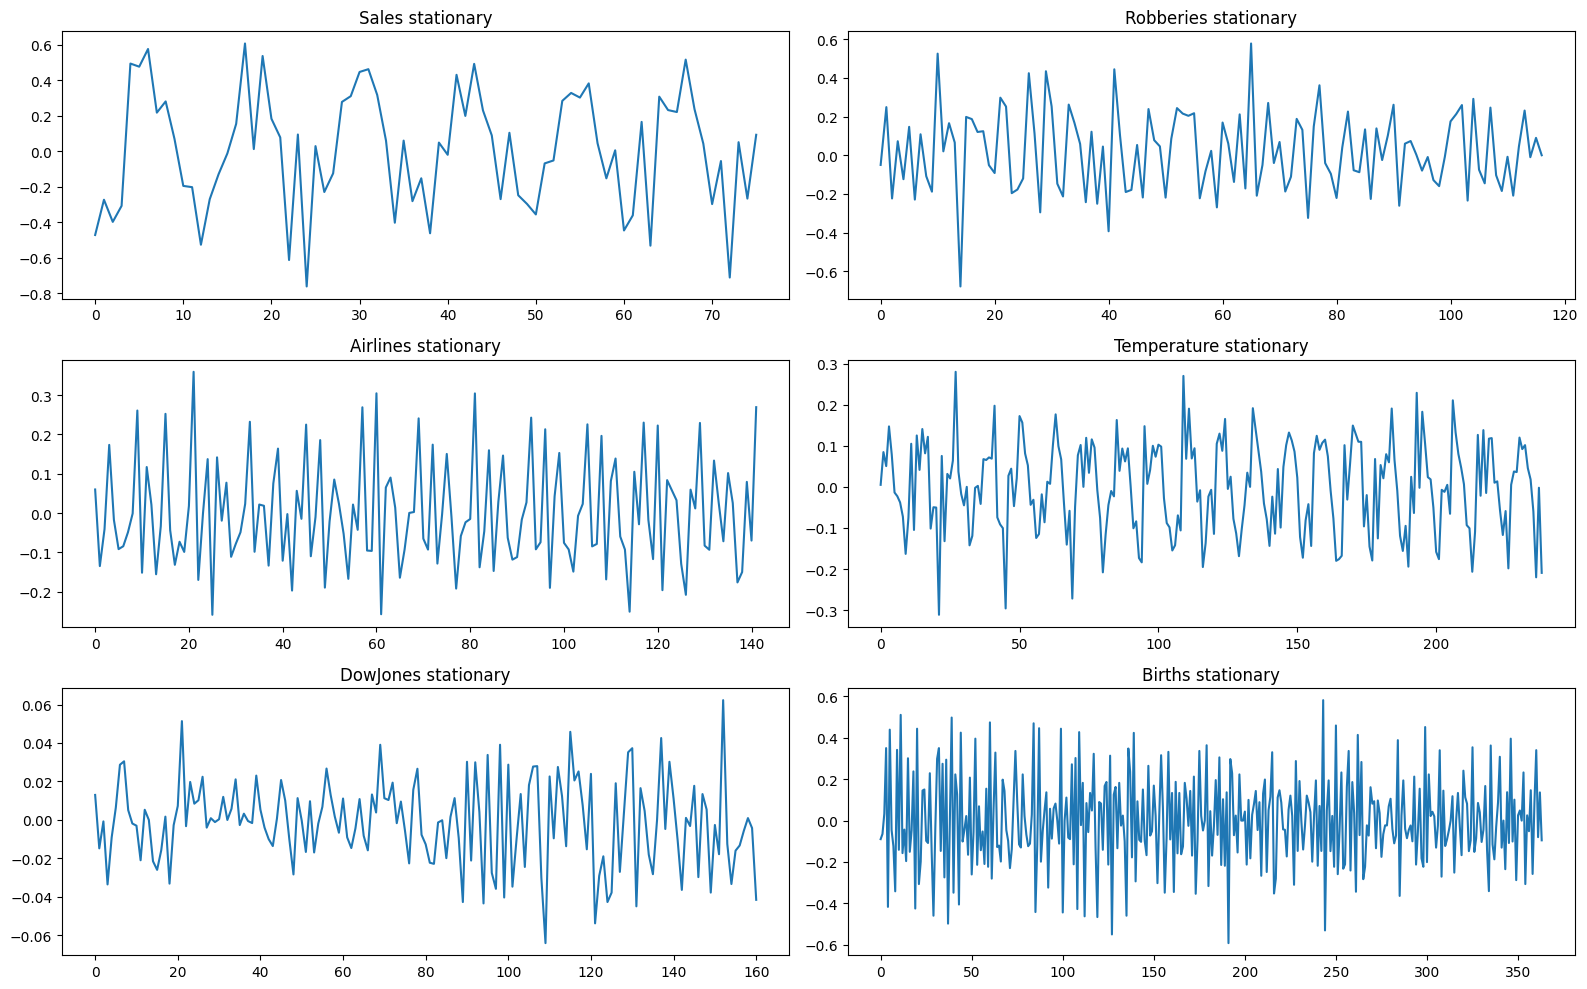

In [19]:
# посмотрела как они выглядят после преобразований
plt.figure(figsize=(16, 10))

for i, key in enumerate(stationary_dict):
    plt.subplot(3, 2, i + 1)
    plt.plot(stationary_dict[key])
    plt.title(key + " stationary")

plt.tight_layout()
plt.show()

In [20]:
# снова проверяю тестом
for name, series in stationary_dict.items():
    adf_test(series, name)

Sales
stat: -3.135643801006635
p-value: 0.024025392839875176
------------------------------
Robberies
stat: -7.601792127269042
p-value: 2.3786024417437596e-11
------------------------------
Airlines
stat: -8.19662913218224
p-value: 7.419304549376186e-13
------------------------------
Temperature
stat: -12.14225999456985
p-value: 1.6407281304676633e-22
------------------------------
DowJones
stat: -12.995820716080098
p-value: 2.7516091322913448e-24
------------------------------
Births
stat: -12.963338685753918
p-value: 3.191204585878006e-24
------------------------------


In [23]:
# функция для графика + автокорреляции
def tsplot(y, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    axes[0].plot(y)
    axes[0].set_title(title)

    smt.graphics.plot_acf(y, lags=30, ax=axes[1])

    plt.tight_layout()
    plt.show()

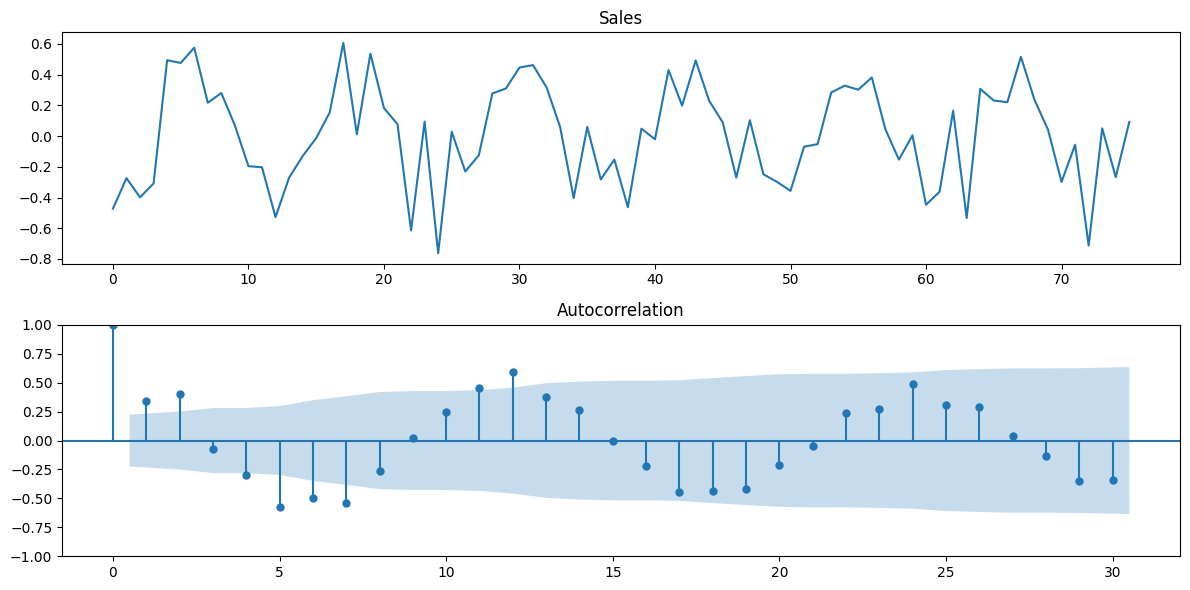

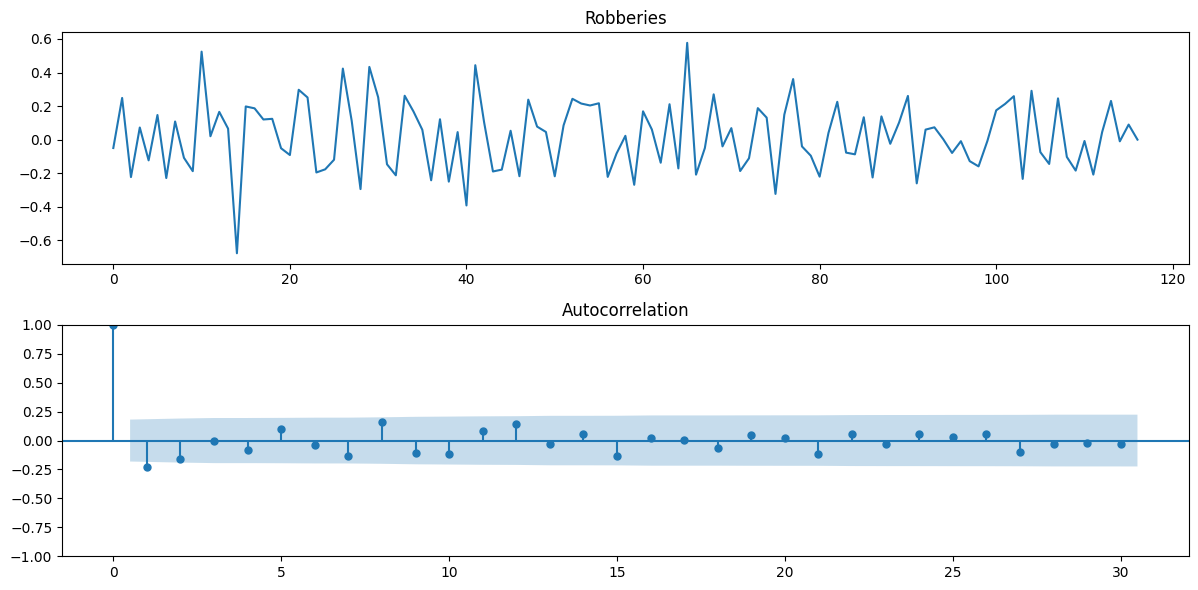

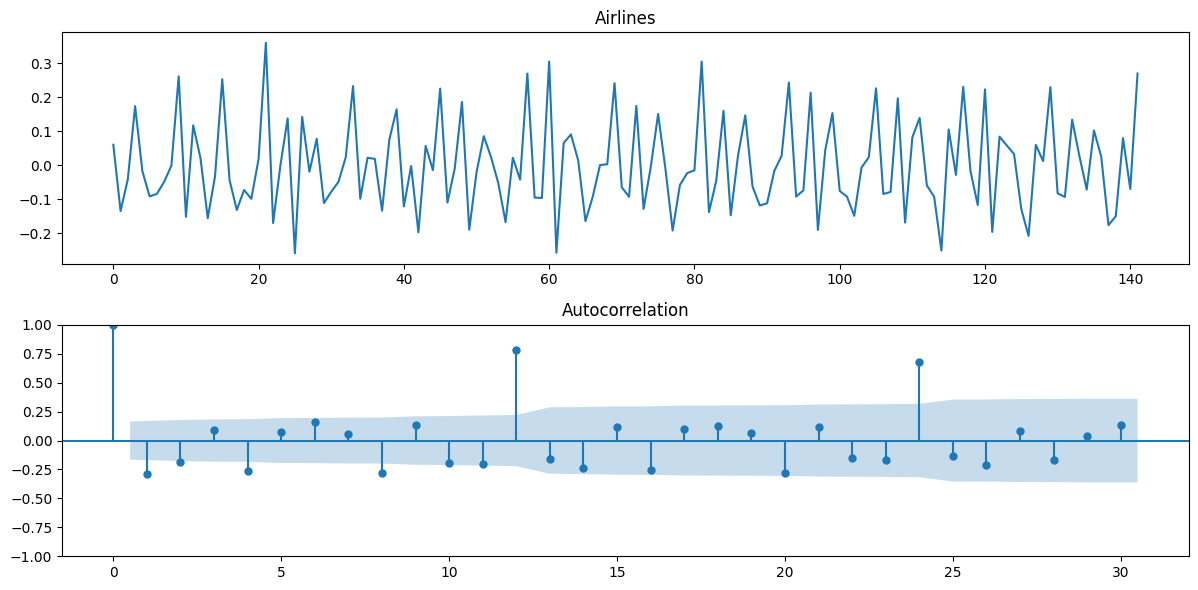

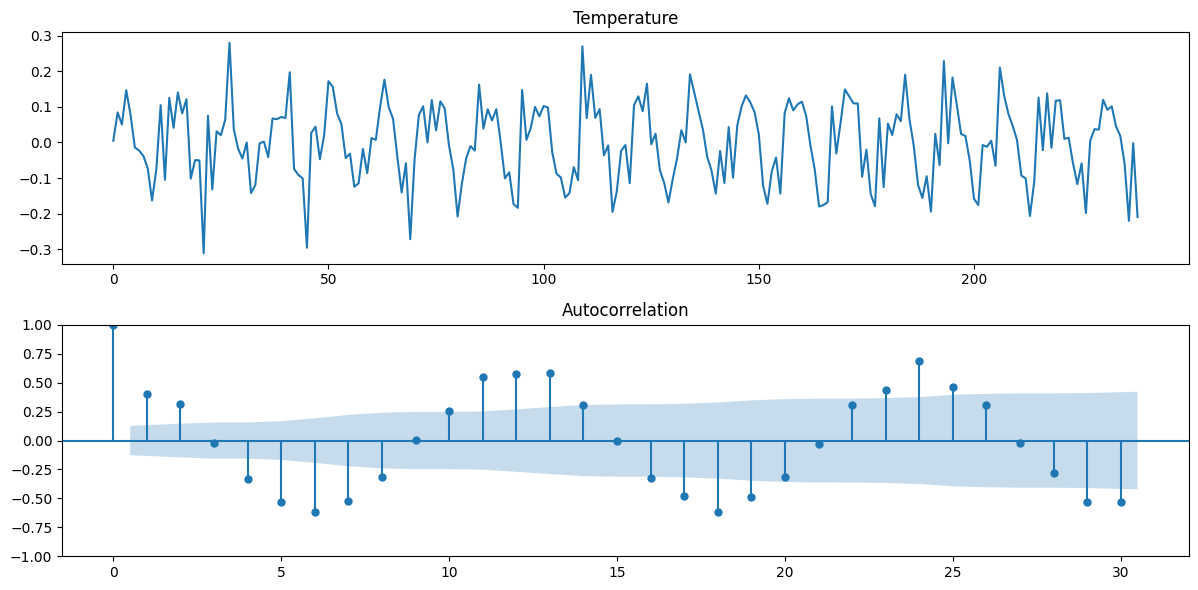

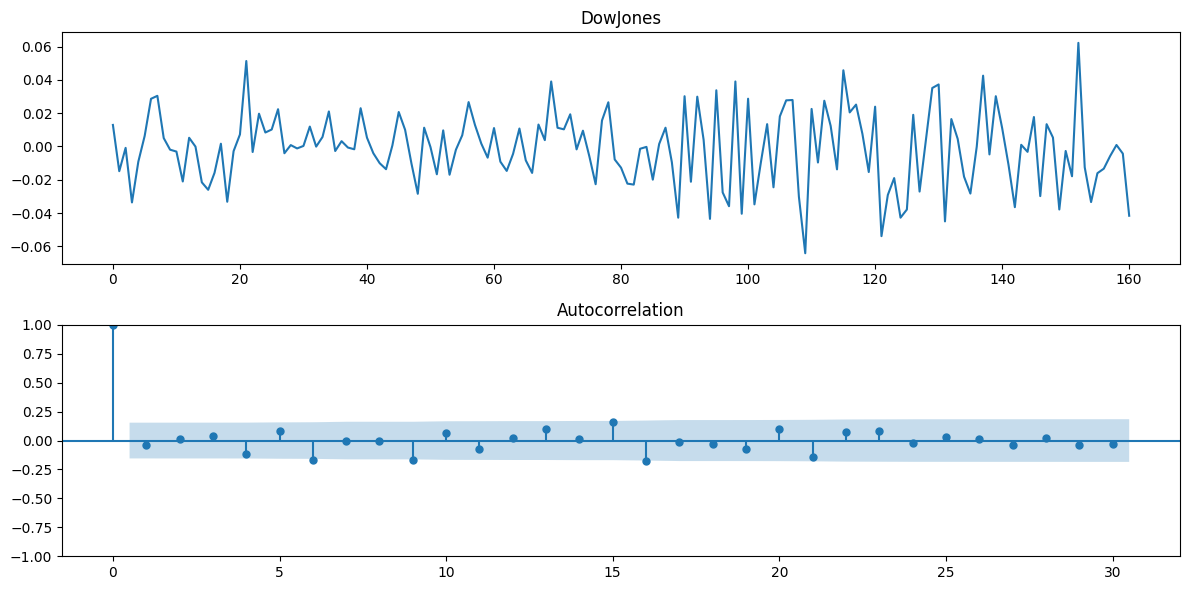

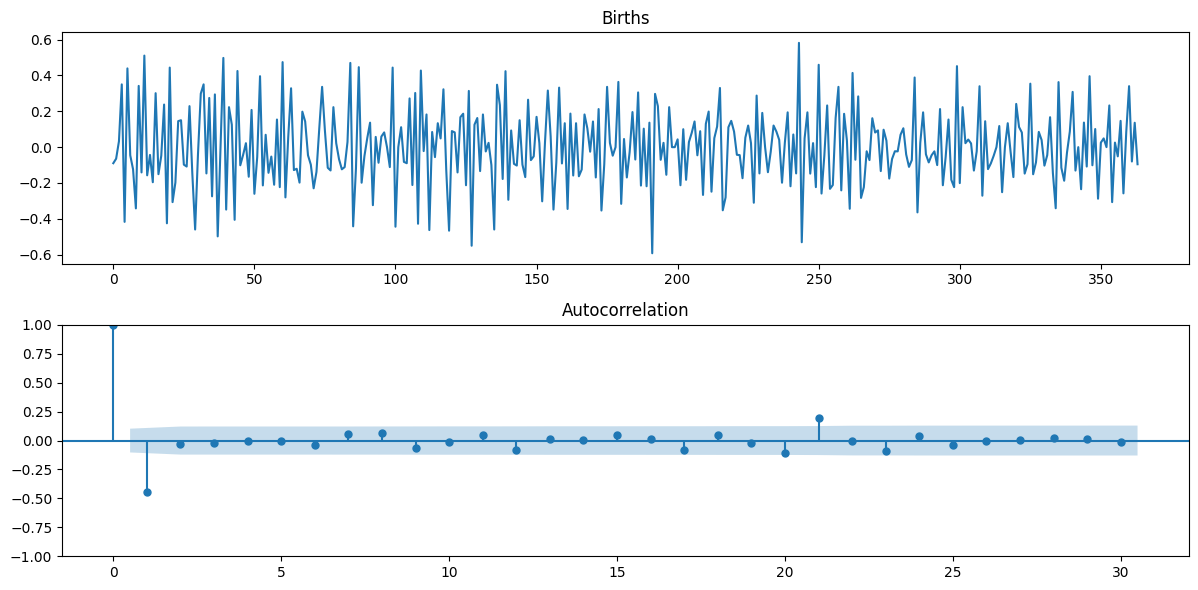

In [24]:
# смотрю ACF
for name, series in stationary_dict.items():
    tsplot(series, name)

Вывод:

Большинство рядов изначально были нестационарными.

Применили Box-Cox и дифференцирование.

После этого ряды стали стационарными.

Это видно по графикам, тесту Дики-Фуллера и ACF.

Ряды готовы для дальнейшего анализа.